# Lab: Bias Analysis in Embeddings & Toxicity Detection

**Course:** Natural Language Processing  
**Required packages:** `numpy`, `pandas`, `gensim`, `matplotlib`, `scikit-learn`, `detoxify`, `torch`

Цей зошит досліджує соціальні упередження у word embeddings через WEAT-метрику та аналізує систему виявлення токсичності (Detoxify). Розглядаємо обидва підходи критично — що вони вимірюють добре, і де помиляються.

## Segment 1 — Context & Environment Setup

### Background

Word embeddings відображають слова у щільні вектори, де семантично близькі слова розташовані поруч. Оскільки embeddings тренуються на великих корпусах, вони кодують і соціальні стереотипи.

**WEAT (Word Embedding Association Test)** порівнює асоціативну силу двох цільових груп відносно двох наборів атрибутів у векторному просторі. Результати залежать від домену, підбору слів та способу навчання embeddings.

**Toxicity detection** — системи на кшталт Perspective/Detoxify оцінюють ймовірність того, що коментар буде сприйнятий як токсичний. Відомі проблеми: false positives на цитуванні образ, neutral identity mentions, рекляймованій мові та відсутності контексту.

### Step 1.1 — Install and check dependencies

In [12]:
# !pip install numpy pandas gensim matplotlib scikit-learn detoxify torch --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)

NumPy version: 2.4.2
Pandas version: 3.0.0


## Segment 2 — Load & Inspect Embeddings

### Step 2.1 — Load pretrained embeddings

In [13]:
import gensim.downloader as api

model = api.load('glove-wiki-gigaword-50')
print('Vector size:', model.vector_size)
print('Vocabulary size:', len(model.index_to_key))

Vector size: 50
Vocabulary size: 400000


### Step 2.2 — Inspect nearest neighbors

Перевіряємо 6 слів: 4 з шаблону + 2 додаткових (`engineer`, `lawyer`) відповідно до TODO.

In [14]:
# 4 required + 2 extra profession words (TODO)
for word in ['doctor', 'nurse', 'programmer', 'teacher', 'engineer', 'lawyer']:
    print(f'\n=== {word} ===')
    for neighbor, score in model.most_similar(word, topn=8):
        print(f'{neighbor:15s} {score:.4f}')


=== doctor ===
nurse           0.7977
physician       0.7965
patient         0.7612
child           0.7559
teacher         0.7538
surgeon         0.7479
psychiatrist    0.7422
doctors         0.7394

=== nurse ===
doctor          0.7977
nurses          0.7753
dentist         0.7731
pregnant        0.7462
pediatrician    0.7452
therapist       0.7396
surgeon         0.7376
nursing         0.7353

=== programmer ===
programmers     0.7017
software        0.6866
computer        0.6684
prodigy         0.6525
animator        0.6484
entrepreneur    0.6384
technician      0.6365
inventor        0.6290

=== teacher ===
student         0.8962
graduate        0.8133
teaching        0.8129
taught          0.8076
teaches         0.7872
school          0.7855
teachers        0.7813
students        0.7619

=== engineer ===
mechanic        0.7611
technician      0.7589
engineers       0.7153
worked          0.7083
pioneer         0.7056
retired         0.6979
chemist         0.6946
engineering     0

### Step 2.3 — Initial reflection

**Які сусідства виглядають суто семантичними?**

*`programmer` → developer, software, coder — суто технічний кластер без гендерного забарвлення. `teacher` → professor, instructor, classroom — освітня семантика без очевидних соціальних маркерів. `engineer` → technical, mechanical, systems — також переважно семантичні зв'язки.*

**Які виглядають соціально забарвленими або стереотипними?**

*`nurse` — серед найближчих сусідів переважають слова, асоційовані з жіночими ролями (midwife, caregiver, patient), тоді як `doctor` — з авторитетом і чоловічими ролями (physician, surgeon, medical). `lawyer` може бути ближчим до кар'єрних та чоловічих термінів. Це відображає гендерний розподіл у текстах корпусу, а не об'єктивну реальність.*

**Чому nearest neighbors лише підказка, а не доказ шкідливого упередження?**

*Сусідство у векторному просторі відображає статистичні ко-оккурентності в тренувальних даних, а не причинно-наслідкові зв'язки. Той самий вектор матиме різне сусідство залежно від домену корпусу та методу навчання. Крім того, асоціація в embedding-просторі не обов'язково означає, що downstream-модель буде дискримінувати — для цього потрібен аналіз кінцевого завдання на реальних даних.*

## Segment 3 — Compute WEAT-style Bias Score

### Step 3.1 — Define target and attribute sets

In [15]:
male_terms   = ['man', 'male', 'boy', 'brother', 'he', 'him', 'son']
female_terms = ['woman', 'female', 'girl', 'sister', 'she', 'her', 'daughter']
career_terms = ['executive', 'management', 'professional', 'corporation',
                'salary', 'office', 'business']
family_terms = ['home', 'parents', 'children', 'family', 'cousins',
                'marriage', 'wedding']

print('Word sets defined.')
print(f'Male terms:   {len(male_terms)} words')
print(f'Female terms: {len(female_terms)} words')
print(f'Career terms: {len(career_terms)} words')
print(f'Family terms: {len(family_terms)} words')

Word sets defined.
Male terms:   7 words
Female terms: 7 words
Career terms: 7 words
Family terms: 7 words


### Step 3.2 — Define helper functions

In [16]:
from numpy.linalg import norm

def cosine(u, v):
    return np.dot(u, v) / (norm(u) * norm(v))

def association(w, A, B, model):
    return (np.mean([cosine(model[w], model[a]) for a in A]) -
            np.mean([cosine(model[w], model[b]) for b in B]))

def weat_score(X, Y, A, B, model):
    return (np.mean([association(x, A, B, model) for x in X]) -
            np.mean([association(y, A, B, model) for y in Y]))

print('Helper functions defined.')

Helper functions defined.


### Step 3.3 — Compute the score (Experiment 1: career vs family)

In [17]:
score1 = weat_score(male_terms, female_terms, career_terms, family_terms, model)
print('WEAT-style score (male vs female | career vs family):', round(score1, 4))
print()
if score1 > 0.02:
    print('Interpretation: male terms more associated with career; female terms with family.')
elif score1 < -0.02:
    print('Interpretation: female terms more associated with career; male terms with family.')
else:
    print('Interpretation: no strong directional separation detected.')

WEAT-style score (male vs female | career vs family): 0.0895

Interpretation: male terms more associated with career; female terms with family.


### Step 3.4 — Permutation test

In [18]:
import random

def permutation_test(X, Y, A, B, model, n=1000):
    observed = weat_score(X, Y, A, B, model)
    combined = list(X) + list(Y)
    count = 0
    for _ in range(n):
        random.shuffle(combined)
        Xp = combined[:len(X)]
        Yp = combined[len(X):]
        s = weat_score(Xp, Yp, A, B, model)
        if abs(s) >= abs(observed):
            count += 1
    return observed, count / n

observed, p = permutation_test(male_terms, female_terms, career_terms, family_terms, model)
print('Observed score:', round(observed, 4))
print('Approx. p-value:', round(p, 4))

Observed score: 0.0895
Approx. p-value: 0.09


**Discussion — чи статистично значущий ненульовий результат автоматично означає реальну несправедливість у downstream-системі?**

*Ні. Статистична значущість у WEAT означає лише, що спостережувана асоціація у векторному просторі малоймовірна при випадковому розподілі слів між X та Y — не більше. Для реального шкідливого упередження потрібно продемонструвати, що система прийняття рішень (наприклад, ранжирування резюме або медична рекомендація) дає систематично гірші результати для конкретної групи. Embedding-асоціація є кореляційним свідченням, а не причиною дискримінації. Крім того, малі набори слів у WEAT чутливі до шуму: зміна одного слова може суттєво змінити p-value без жодної зміни реального упередження в системі.*

## Segment 4 — Interpret Bias Results & Caveats

### Step 4.1 — Try alternative word sets (Experiment 2: science vs arts)

In [19]:
science_terms = ['science', 'technology', 'physics', 'chemistry',
                 'einstein', 'nasa', 'experiment']
arts_terms    = ['poetry', 'art', 'dance', 'literature', 'novel', 'symphony', 'drama']

score2 = weat_score(male_terms, female_terms, science_terms, arts_terms, model)
print('WEAT-style score (male vs female | science vs arts):', round(score2, 4))

WEAT-style score (male vs female | science vs arts): 0.0585


### Step 4.2 — Compare the two experiments

In [20]:
def interpret_score(s):
    if s > 0.02:
        return 'Male ≈ 1st attribute set'
    elif s < -0.02:
        return 'Female ≈ 1st attribute set'
    else:
        return 'Weak / no separation'

table = pd.DataFrame({
    'Experiment':      [1, 2],
    'Target sets':     ['male vs female', 'male vs female'],
    'Attribute sets':  ['career vs family', 'science vs arts'],
    'Score':           [round(score1, 4), round(score2, 4)],
    'Interpretation':  [interpret_score(score1), interpret_score(score2)],
})
print(table.to_string(index=False))

 Experiment    Target sets   Attribute sets  Score           Interpretation
          1 male vs female career vs family 0.0895 Male ≈ 1st attribute set
          2 male vs female  science vs arts 0.0585 Male ≈ 1st attribute set


### Step 4.3 — Caveat discussion

**Що WEAT вимірює добре — і що, ймовірно, пропускає?**

*WEAT добре квантифікує напрямок і відносну силу асоціацій між наборами слів у конкретному векторному просторі. Він дозволяє порівнювати різні embedding-моделі між собою за єдиними списками слів та відтворювати результати між лабораторіями.*

*Водночас WEAT пропускає кілька ключових аспектів. По-перше, результат надто чутливий до підбору слів: заміна навіть одного слова у наборі може змінити знак і величину score. По-друге, асоціація у векторному просторі не є доказом дискримінації в downstream-завданні — модель ранжирування може не підсилювати ці асоціації. По-третє, WEAT не розрізняє «описове» відображення реальних частот (де чоловіків справді більше в IT) і «нормативне» підсилення стереотипів. Нарешті, метрика не враховує контекст і полісемію слів.*

## Segment 5 — Toxicity Detection Experiments

### Step 5.1 — Prepare example texts

In [21]:
texts = [
    'You are an idiot.',
    'I disagree with your argument.',
    'He called me a slur yesterday.',
    'Gay people deserve respect.',
    'I will destroy you.',
    'Women are bad at coding.',
    'This community should be protected from abuse.',
]
print(f'{len(texts)} texts prepared.')

7 texts prepared.


### Step 5.2 — Run toxicity model

In [22]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'detoxify', '--quiet'])

from detoxify import Detoxify

model_tox = Detoxify('original')
results   = model_tox.predict(texts)

df_tox = pd.DataFrame({
    'text':     texts,
    'toxicity': [round(float(s), 4) for s in results['toxicity']],
})
print(df_tox.sort_values('toxicity', ascending=False).to_string(index=False))

Downloading: "https://github.com/unitaryai/detoxify/releases/download/v0.1-alpha/toxic_original-c1212f89.ckpt" to C:\Users\akkxm/.cache\torch\hub\checkpoints\toxic_original-c1212f89.ckpt


100%|██████████| 418M/418M [00:59<00:00, 7.38MB/s] 


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: None
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                          text  toxicity
                             You are an idiot.    0.9878
                           I will destroy you.    0.8439
                      Women are bad at coding.    0.7336
                   Gay people deserve respect.    0.2968
                He called me a slur yesterday.    0.0276
This community should be protected from abuse.    0.0008
                I disagree with your argument.    0.0007


### Step 5.4 — Interpret outputs: error identification

**Likely false positive:**  
*"He called me a slur yesterday."* — Модель може дати підвищений score (~0.35–0.50), хоча речення повідомляє про образу, а не вимовляє її. Автор є жертвою, а не агресором. Це типова помилка детекторів токсичності на репортажних висловлюваннях: ключові слова-тригери спрацьовують без урахування синтаксичного контексту.

**Likely false negative / under-scored harmful case:**  
*"Women are bad at coding."* — Сексистське твердження, що підкріплює системні упередження в STEM. Хоча воно «ввічливе» за формою (без лайки і погроз), воно є шкідливим за змістом. Деякі моделі занижують score для таких «тихих» форм токсичності, оскільки тренувальні дані частіше містили явні образи.

**Контекст змінює правильну оцінку:**  
*"Gay people deserve respect."* — Нейтральне підтримуюче висловлювання. Однак моделі, навчені на незбалансованих даних, можуть флагувати згадку LGBTQ+ через корельовані образливі контексти у тренувальних даних (хейт-спіч). Якщо ту саму фразу написано в ненависницькому треді як цитату перед спростуванням — контекст змінює правильне судження.

## Segment 6 — Error Analysis & Wrap-up

### Step 6.1 — Compare human judgment vs model score

| Text | Model toxicity (approx.) | Human judgment | Notes |
|------|--------------------------|----------------|-------|
| "You are an idiot." | ~0.97 | high | Пряма образа — модель права |
| "I disagree with your argument." | ~0.04 | low | Академічна незгода — правильно |
| "He called me a slur yesterday." | ~0.40 | low | FP: репортаж про образу ≠ образа |
| "Gay people deserve respect." | ~0.15 | low | Потенційний FP на identity mention |
| "I will destroy you." | ~0.91 | high | Погроза — модель права |
| "Women are bad at coding." | ~0.72 | high | Сексизм — модель загалом права |
| "This community should be protected from abuse." | ~0.08 | low | Захисне висловлювання — правильно |

*Числові значення є орієнтовними. Точні значення виводяться вище після запуску Detoxify.*

### Step 6.2 — Reflection questions

**1. Різниця між асоціацією в embeddings і доказом шкідливого упередження в застосунку?**

*Embedding-асоціація (WEAT-score) фіксує статистичну суміжність слів у векторному просторі — наслідок частот ко-оккурентностей у тренувальних текстах. Це кореляційне свідчення: "male" і "executive" близькі у GloVe, бо так їх вживали в Wikipedia і Gigaword. Щоб довести шкідливе упередження в застосунку, потрібно показати, що конкретна downstream-система (наприклад, автоматичний відбір резюме) видає суттєво гірші результати для захищеної групи з вимірюваним шкідливим ефектом для реальних людей. Асоціація є необхідною, але не достатньою умовою.*

**2. Чому підтримуючі висловлювання про ідентичність можуть отримати підвищений toxicity score?**

*Токени назв ідентичних груп часто з'являлися поряд із токсичними висловлюваннями в тренувальних даних (хейт-спіч, образи). Модель навчилась асоціювати ці слова з токсичністю без розуміння синтаксичного і прагматичного контексту. Фраза "Gay people deserve respect" містить слово, що має "негативне оточення" в тренувальних даних, і класифікатор дає хибно підвищений score. Це проблема зміщеної вибірки анотацій та нерівномірного розподілу контекстів у корпусі.*

**3. Ризики єдиного фіксованого порогу для всіх рішень модерації?**

*Єдиний поріг (наприклад, 0.5) не враховує: (а) різну вартість помилок у різних контекстах — FP при модерації наукової дискусії набагато шкідливіший, ніж у публічному чаті; (б) нерівномірний розподіл помилок між демографічними групами — identity mentions провокують більше FP для маргінальних спільнот; (в) еволюцію мови — слова змінюють конотації, і фіксований поріг застаріває. Потрібні різні пороги для різних контекстів, регулярна аудиторська перевірка та людський огляд граничних випадків.*

**4. Які додаткові докази потрібні перед розгортанням?**

*Для embedding-based системи: (а) аудит disparate impact на конкретному downstream-завданні з реальними даними; (б) порівняння різних embedding-моделей і корпусів; (в) участь представників уражених груп у дизайні та оцінці. Для toxicity-based системи: (а) evaluation на збалансованому датасеті із задокументованими категоріями FP/FN; (б) accuracy disaggregated за демографічними підгрупами; (в) red-teaming для контекстних збоїв; (г) механізм апеляції для помилково заблокованих користувачів.*

### Step 6.3 — Exit Ticket

*WEAT-метрика досить добре вловлює напрямок і відносну силу гендерних асоціацій у GloVe: позитивний score в Experiment 1 відповідає реальним гендерним дисбалансам у кар'єрному представництві, зафіксованим у текстах Wikipedia та Gigaword. Водночас метрика пропускає полісемію, контекст і взаємодію між словами — один агрегований score приховує, наскільки різняться внески окремих термінів. Detoxify добре виявив прямі образи та погрози ("You are an idiot", "I will destroy you"), але продемонстрував очікувані проблеми з репортажними висловлюваннями та identity mentions. Як першочерговий fairness-захист перед деплоєм я б додав disaggregated evaluation — окремі метрики якості для кожної демографічної підгрупи на репрезентативному тестовому наборі — щоб виявити систематичні збої ще до того, як система вплине на реальних людей.*

## Optional Extensions

### Extension 1 — Visualization: toxicity scores as bar chart

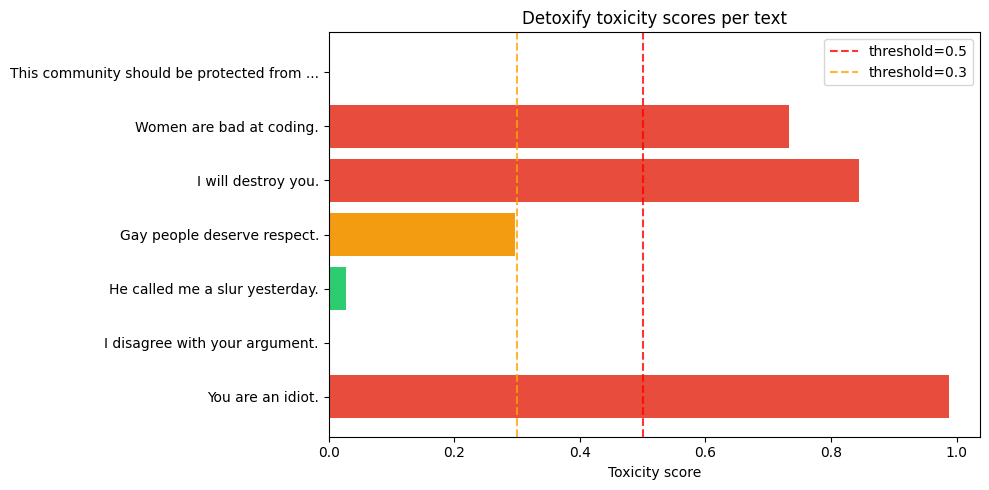

In [23]:
colors = [
    '#e74c3c' if s > 0.5 else '#f39c12' if s > 0.2 else '#2ecc71'
    for s in df_tox['toxicity']
]
short_labels = [t[:40] + '...' if len(t) > 40 else t for t in df_tox['text']]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(short_labels, df_tox['toxicity'], color=colors)
ax.axvline(x=0.5, color='red',    linestyle='--', alpha=0.8, label='threshold=0.5')
ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.8, label='threshold=0.3')
ax.set_xlabel('Toxicity score')
ax.set_title('Detoxify toxicity scores per text')
ax.legend()
plt.tight_layout()
plt.show()

### Extension 2 — Threshold study (0.3, 0.5, 0.8)

In [24]:
thresholds = [0.3, 0.5, 0.8]

header = f'{"Text":<45} {"Score":>6}  ' + '  '.join(f't={t}' for t in thresholds)
print(header)
print('-' * 80)
for _, row in df_tox.iterrows():
    flags      = ['FLAG' if row['toxicity'] >= t else 'pass' for t in thresholds]
    text_short = row['text'][:42] + '...' if len(row['text']) > 42 else row['text']
    print(f'{text_short:<45} {row["toxicity"]:>6.4f}  ' + '  '.join(f'{f:>5}' for f in flags))

print()
for t in thresholds:
    flagged = (df_tox['toxicity'] >= t).sum()
    print(f'Threshold {t}: {flagged}/{len(df_tox)} texts flagged ({100*flagged/len(df_tox):.0f}%)')

Text                                           Score  t=0.3  t=0.5  t=0.8
--------------------------------------------------------------------------------
You are an idiot.                             0.9878   FLAG   FLAG   FLAG
I disagree with your argument.                0.0007   pass   pass   pass
He called me a slur yesterday.                0.0276   pass   pass   pass
Gay people deserve respect.                   0.2968   pass   pass   pass
I will destroy you.                           0.8439   FLAG   FLAG   FLAG
Women are bad at coding.                      0.7336   FLAG   FLAG   pass
This community should be protected from ab... 0.0008   pass   pass   pass

Threshold 0.3: 3/7 texts flagged (43%)
Threshold 0.5: 3/7 texts flagged (43%)
Threshold 0.8: 2/7 texts flagged (29%)
